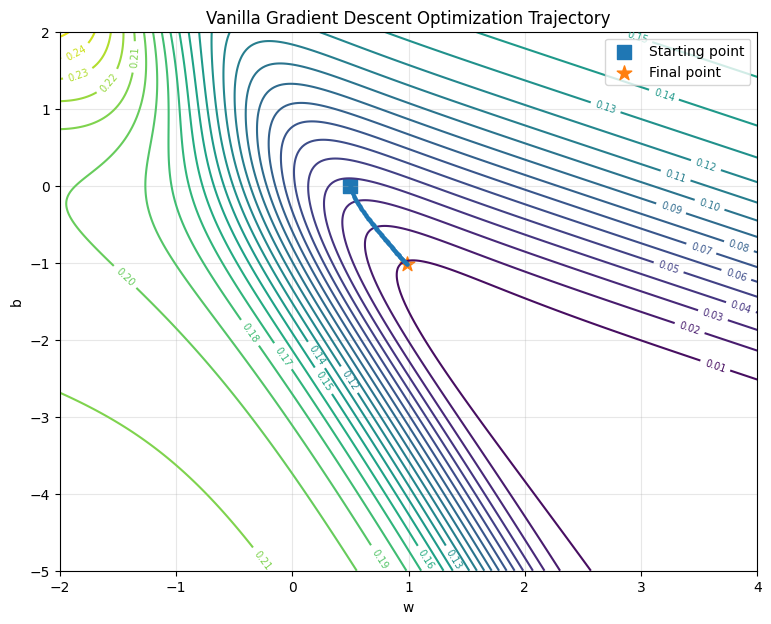

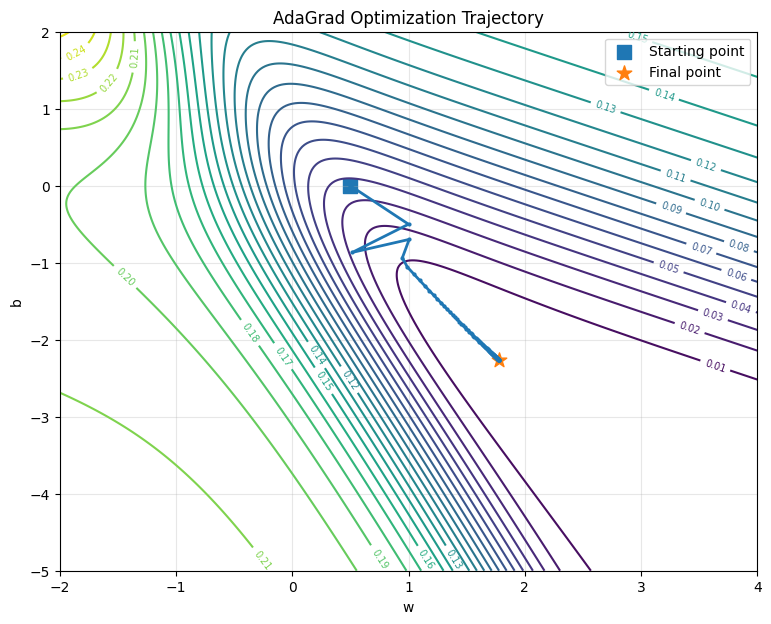

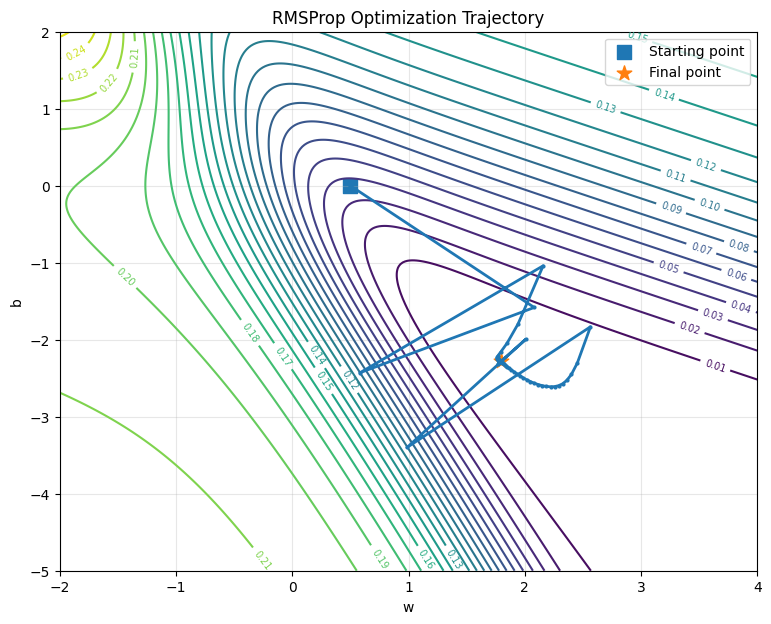

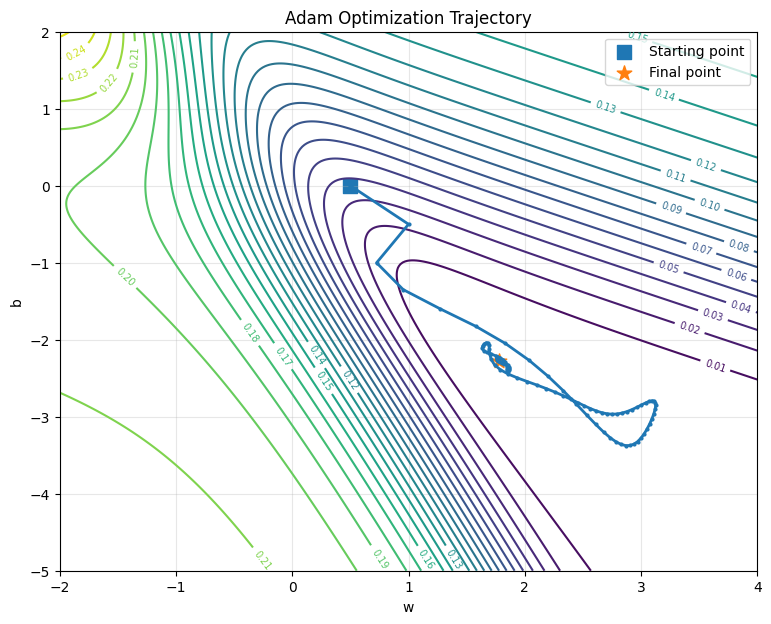

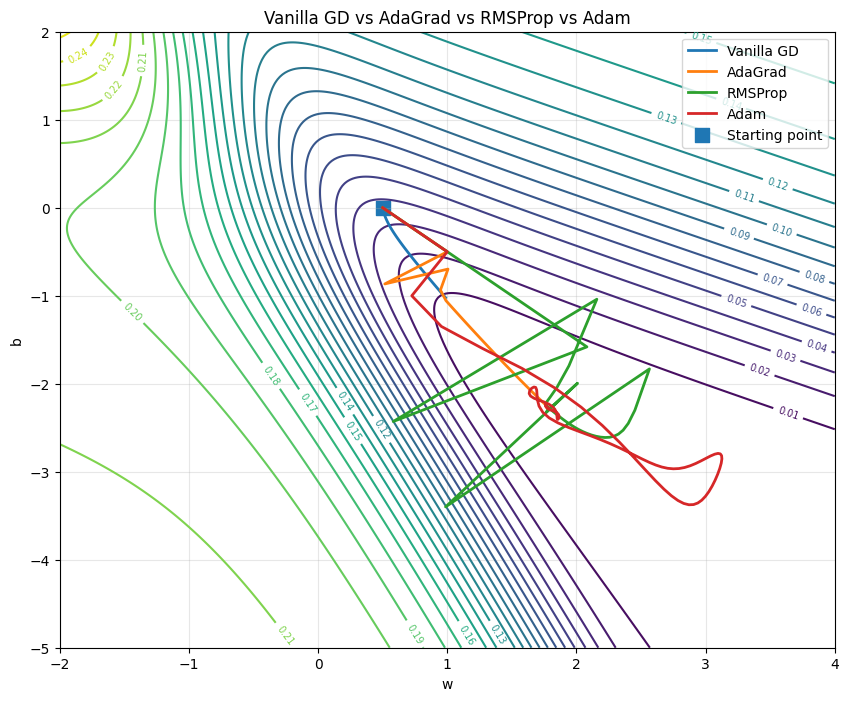

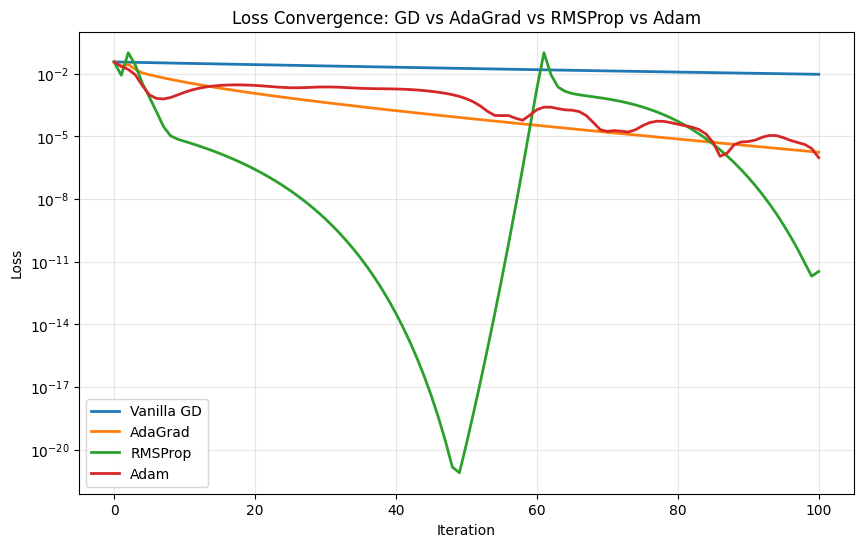

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# DATASET
# ============================================================

X = np.array([0.5, 2.5])
Y = np.array([0.2, 0.9])

W0 = 0.5
B0 = 0.0

LR = 0.5

EPOCHS = 100

EPSILON = 1e-8


# ============================================================
# SIGMOID
# ============================================================

def sigmoid(z):

    return 1 / (
        1 + np.exp(
            -np.clip(z, -500, 500)
        )
    )


# ============================================================
# LOSS
# ============================================================

def loss(w, b):

    y_pred = sigmoid(w * X + b)

    return 0.5 * np.mean(
        (y_pred - Y) ** 2
    )


# ============================================================
# GRADIENT
# ============================================================

def gradient(w, b):

    y_pred = sigmoid(w * X + b)

    error = y_pred - Y

    grad_w = np.mean(
        error * y_pred *
        (1 - y_pred) * X
    )

    grad_b = np.mean(
        error * y_pred *
        (1 - y_pred)
    )

    return grad_w, grad_b


# ============================================================
# VANILLA GD
# ============================================================

def vanilla_gd():

    w = W0
    b = B0

    trajectory = [(w, b)]
    losses = [loss(w, b)]

    for epoch in range(EPOCHS):

        grad_w, grad_b = gradient(w, b)

        w -= LR * grad_w
        b -= LR * grad_b

        trajectory.append((w, b))
        losses.append(loss(w, b))

    return np.array(trajectory), np.array(losses)


# ============================================================
# ADAGRAD
# ============================================================

def adagrad():

    w = W0
    b = B0

    accumulated_w = 0
    accumulated_b = 0

    trajectory = [(w, b)]
    losses = [loss(w, b)]

    for epoch in range(EPOCHS):

        grad_w, grad_b = gradient(w, b)

        # Accumulate squared gradients
        accumulated_w += grad_w ** 2
        accumulated_b += grad_b ** 2

        # Adaptive update
        w -= (
            LR * grad_w /
            (np.sqrt(accumulated_w) + EPSILON)
        )

        b -= (
            LR * grad_b /
            (np.sqrt(accumulated_b) + EPSILON)
        )

        trajectory.append((w, b))
        losses.append(loss(w, b))

    return np.array(trajectory), np.array(losses)


# ============================================================
# RMSPROP
# ============================================================

def rmsprop(beta=0.9):

    w = W0
    b = B0

    squared_avg_w = 0
    squared_avg_b = 0

    trajectory = [(w, b)]
    losses = [loss(w, b)]

    for epoch in range(EPOCHS):

        grad_w, grad_b = gradient(w, b)

        # Exponential moving average
        squared_avg_w = (
            beta * squared_avg_w
            + (1 - beta) * grad_w ** 2
        )

        squared_avg_b = (
            beta * squared_avg_b
            + (1 - beta) * grad_b ** 2
        )

        # Update
        w -= (
            LR * grad_w /
            (np.sqrt(squared_avg_w) + EPSILON)
        )

        b -= (
            LR * grad_b /
            (np.sqrt(squared_avg_b) + EPSILON)
        )

        trajectory.append((w, b))
        losses.append(loss(w, b))

    return np.array(trajectory), np.array(losses)


# ============================================================
# ADAM
# ============================================================

def adam(
    beta1=0.9,
    beta2=0.999
):

    w = W0
    b = B0

    # First moments
    m_w = 0
    m_b = 0

    # Second moments
    v_w = 0
    v_b = 0

    trajectory = [(w, b)]
    losses = [loss(w, b)]

    for t in range(1, EPOCHS + 1):

        grad_w, grad_b = gradient(w, b)

        # First moment
        m_w = (
            beta1 * m_w
            + (1 - beta1) * grad_w
        )

        m_b = (
            beta1 * m_b
            + (1 - beta1) * grad_b
        )

        # Second moment
        v_w = (
            beta2 * v_w
            + (1 - beta2) * grad_w ** 2
        )

        v_b = (
            beta2 * v_b
            + (1 - beta2) * grad_b ** 2
        )

        # Bias correction
        m_w_hat = (
            m_w /
            (1 - beta1 ** t)
        )

        m_b_hat = (
            m_b /
            (1 - beta1 ** t)
        )

        v_w_hat = (
            v_w /
            (1 - beta2 ** t)
        )

        v_b_hat = (
            v_b /
            (1 - beta2 ** t)
        )

        # Parameter update
        w -= (
            LR * m_w_hat /
            (np.sqrt(v_w_hat) + EPSILON)
        )

        b -= (
            LR * m_b_hat /
            (np.sqrt(v_b_hat) + EPSILON)
        )

        trajectory.append((w, b))
        losses.append(loss(w, b))

    return np.array(trajectory), np.array(losses)


# ============================================================
# ERROR SURFACE
# ============================================================

w_values = np.linspace(-2, 4, 300)
b_values = np.linspace(-5, 2, 300)

W, B = np.meshgrid(
    w_values,
    b_values
)

Z = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):

        Z[i, j] = loss(
            W[i, j],
            B[i, j]
        )


# ============================================================
# RUN OPTIMIZERS
# ============================================================

gd_traj, gd_loss = vanilla_gd()

adagrad_traj, adagrad_loss = adagrad()

rmsprop_traj, rmsprop_loss = rmsprop()

adam_traj, adam_loss = adam()
def plot_trajectory(name, trajectory):

    plt.figure(figsize=(9, 7))

    # Error surface
    contours = plt.contour(
        W,
        B,
        Z,
        levels=25
    )

    plt.clabel(
        contours,
        inline=True,
        fontsize=7
    )

    # This optimizer only
    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        linewidth=2,
        marker="o",
        markersize=2
    )

    # Starting point
    plt.scatter(
        W0,
        B0,
        s=100,
        marker="s",
        label="Starting point"
    )

    # Final point
    plt.scatter(
        trajectory[-1, 0],
        trajectory[-1, 1],
        s=120,
        marker="*",
        label="Final point"
    )

    plt.xlabel("w")
    plt.ylabel("b")

    plt.title(
        f"{name} Optimization Trajectory"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()
plot_trajectory(
    "Vanilla Gradient Descent",
    gd_traj
)

plot_trajectory(
    "AdaGrad",
    adagrad_traj
)

plot_trajectory(
    "RMSProp",
    rmsprop_traj
)

plot_trajectory(
    "Adam",
    adam_traj
)

# ============================================================
# TRAJECTORY COMPARISON
# ============================================================

plt.figure(figsize=(10, 8))

contours = plt.contour(
    W,
    B,
    Z,
    levels=25
)

plt.clabel(
    contours,
    inline=True,
    fontsize=7
)

plt.plot(
    gd_traj[:, 0],
    gd_traj[:, 1],
    linewidth=2,
    label="Vanilla GD"
)

plt.plot(
    adagrad_traj[:, 0],
    adagrad_traj[:, 1],
    linewidth=2,
    label="AdaGrad"
)

plt.plot(
    rmsprop_traj[:, 0],
    rmsprop_traj[:, 1],
    linewidth=2,
    label="RMSProp"
)

plt.plot(
    adam_traj[:, 0],
    adam_traj[:, 1],
    linewidth=2,
    label="Adam"
)

plt.scatter(
    W0,
    B0,
    s=100,
    marker="s",
    label="Starting point"
)

plt.xlabel("w")
plt.ylabel("b")

plt.title(
    "Vanilla GD vs AdaGrad vs RMSProp vs Adam"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# LOSS COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    gd_loss,
    linewidth=2,
    label="Vanilla GD"
)

plt.plot(
    adagrad_loss,
    linewidth=2,
    label="AdaGrad"
)

plt.plot(
    rmsprop_loss,
    linewidth=2,
    label="RMSProp"
)

plt.plot(
    adam_loss,
    linewidth=2,
    label="Adam"
)

plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.title(
    "Loss Convergence: GD vs AdaGrad vs RMSProp vs Adam"
)

plt.yscale("log")

plt.legend()
plt.grid(alpha=0.3)

plt.show()